<div style="text-align: right;">
    <img src="images\Kaasrahastanud_EL_kaksiklogod_ENG_hor_color_RGB.jpg" width="300">
</div>

<p style="text-align: right;">
Marta Jemeļjanova
</p>
<p style="text-align: right;">
University of Tartu
</p>

<h2 style="text-align: center;">Hackaton solution</h2>
<h1 style="text-align: center;">Aboveground biomass modeling via Earth Observation</h1>

This solution has the following workflow:
1) As the processing power is limited, select representative sample (based on prediction target of the whole train dataset)
2) Assess covariate/feature correlation, eliminate those that: a) don't correlate with the prediction target (threshold 0.1) b) correlate with each other of at least 0.8 (method generally follows DOI).
3) Use SHAP to evaluate feature importances, eliminate those that don't have strong directional contribution to AGB values.

In [1]:
import pandas as pd
import os
import geopandas as gpd
import math
import numpy as np
from shapely.geometry import box

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.utils.validation import check_X_y
from sklearn.model_selection import KFold
from sklearn import set_config
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error

set_config(display="text")
randomstate = 0

import shap

C:\Users\martajem\AppData\Local\miniconda3\envs\ogh_ss\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Import train and test data

In [2]:
train = pd.read_csv('train.csv')

train = train.dropna()

In [3]:
train

,Unnamed: 0,x,y,b02_s2.cdse.quarterly_xxxx0401_xxxx0631,b04_s2.cdse.quarterly_xxxx0401_xxxx0631,b08_s2.cdse.quarterly_xxxx0401_xxxx0631,obs_s2.cdse.quarterly_xxxx0401_xxxx0631,HH_dB_palsar_xxxx,HV_dB_palsar_xxxx,angle_palsar_xxxx,qa_palsar_xxxx,vv.sentinel1_xxxx07,vh.sentinel1_xxxx07,biomass,bioregion,forest_type,year,tile_id
0,0,3.135535e+06,1.811074e+06,297.0,388.0,2642.0,11.0,-5.108930,-9.999385,52.704777,255.0,1493.0,453.0,-9999.000000,9.0,10.0,2020,38052
1,1,3.137125e+06,1.810804e+06,306.0,422.0,2632.0,10.0,-7.452171,-12.639405,51.086891,255.0,1097.0,502.0,28.742064,9.0,9.0,2020,38052
2,2,3.136195e+06,1.810234e+06,339.0,506.0,2366.0,9.0,-7.149265,-11.757082,48.271122,255.0,1690.0,394.0,-9999.000000,9.0,10.0,2020,38052
3,3,3.138085e+06,1.808544e+06,292.0,380.0,3400.0,8.0,-7.566631,-12.543831,47.825680,255.0,2066.0,579.0,61.379017,9.0,9.0,2020,38052
4,4,3.136835e+06,1.809904e+06,453.0,606.0,2684.0,11.0,-7.491881,-11.670959,43.808136,255.0,2264.0,418.0,41.445705,9.0,9.0,2020,38052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16019995,16019995,3.112185e+06,2.244064e+06,464.0,557.0,3496.0,10.0,-15.008804,-29.679758,37.881863,255.0,650.0,83.0,-9999.000000,9.0,0.0,2019,35805
16019996,16019996,3.111705e+06,2.245134e+06,550.0,888.0,2242.0,10.0,-9.913370,-22.194555,33.187073,255.0,566.0,111.0,-9999.000000,9.0,0.0,2019,35805
16019997,16019997,3.111385e+06,2.244714e+06,513.0,794.0,3276.0,12.0,-17.428823,-28.818821,35.111576,255.0,585.0,81.0,-9999.000000,9.0,0.0,2019,35805
16019998,16019998,3.112375e+06,2.244104e+06,366.0,417.0,3688.0,9.0,-16.815596,-31.209925,38.825451,255.0,603.0,66.0,-9999.000000,9.0,0.0,2019,35805


In [4]:
test = pd.read_csv('test.csv')

In [5]:
test

,Unnamed: 0,row_id,x,y,b02_s2.cdse.quarterly_xxxx0401_xxxx0631,b04_s2.cdse.quarterly_xxxx0401_xxxx0631,b08_s2.cdse.quarterly_xxxx0401_xxxx0631,obs_s2.cdse.quarterly_xxxx0401_xxxx0631,HH_dB_palsar_xxxx,HV_dB_palsar_xxxx,angle_palsar_xxxx,qa_palsar_xxxx,vv.sentinel1_xxxx07,vh.sentinel1_xxxx07,bioregion,forest_type,year,tile_id
0,24,028631_3040064_2251003,3.040065e+06,2.251004e+06,100.0,103.0,2788.0,21.0,-10.144670,-13.913869,62.935490,255.0,4345.0,1192.0,9.0,9.0,2021,28631
1,30,028631_3041214_2252063,3.041215e+06,2.252064e+06,171.0,208.0,2746.0,20.0,-7.349724,-10.590984,42.061958,255.0,1360.0,335.0,9.0,9.0,2021,28631
2,33,028631_3041184_2251693,3.041185e+06,2.251694e+06,98.0,91.0,3664.0,21.0,-6.874915,-12.238380,41.123703,255.0,2078.0,615.0,9.0,9.0,2021,28631
3,38,028631_3039864_2250783,3.039865e+06,2.250784e+06,98.0,131.0,3060.0,20.0,-5.991528,-10.575653,52.339672,255.0,2116.0,548.0,9.0,9.0,2021,28631
4,64,028631_3040224_2251483,3.040225e+06,2.251484e+06,72.0,88.0,3772.0,22.0,-6.046557,-10.341457,48.277470,255.0,2367.0,385.0,9.0,9.0,2021,28631
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45014,884113,061751_3374644_2043173,3.374645e+06,2.043174e+06,287.0,323.0,4392.0,17.0,-9.803984,-15.310058,37.016045,255.0,1363.0,397.0,9.0,9.0,2020,61751
45015,885387,061751_3374594_2043203,3.374595e+06,2.043204e+06,608.0,922.0,3732.0,17.0,-11.813272,-15.730301,38.029926,255.0,1387.0,277.0,9.0,0.0,2020,61751
45016,890670,061751_3374624_2043173,3.374625e+06,2.043174e+06,212.0,268.0,3086.0,17.0,-11.729067,-16.882254,36.219688,255.0,1336.0,308.0,9.0,9.0,2020,61751
45017,895641,061751_3374614_2043223,3.374615e+06,2.043224e+06,153.0,215.0,3280.0,17.0,-7.831328,-13.507510,35.155594,255.0,2629.0,603.0,9.0,0.0,2020,61751


## 2. Check whether the test data intersects with train data, i.e. the task is not to extrapolate.

In [6]:
def create_bbox(df):

    # create a geodataframe by passing coordinates
    gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["x"], df["y"]),
    crs="EPSG:3035")

    # find extent of the points
    x_min, y_min, x_max, y_max = gdf.total_bounds

    # create bbox
    bbox = box(x_min, y_min, x_max, y_max)

    # Put bbox into a GeoDataFrame
    bbox_gdf = gpd.GeoDataFrame(
    {"geometry": [bbox]},
    crs=gdf.crs)

    return bbox_gdf, gdf

In [7]:
bbox_train, gdf_train = create_bbox(train)

bbox_test, gdf_test = create_bbox(test)

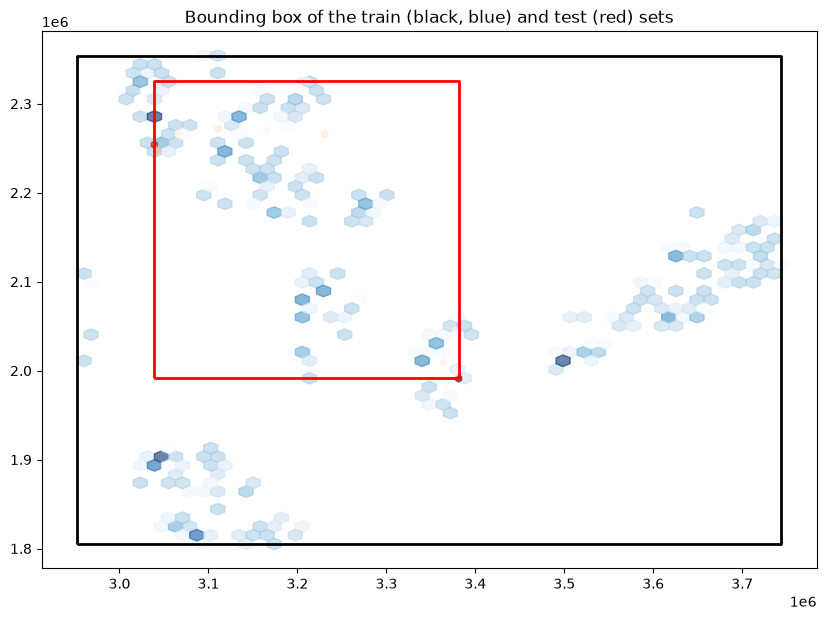

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))

# Bounding boxes
bbox_train.boundary.plot(
    ax=ax,
    linewidth=2,
    color='black'
)

bbox_test.boundary.plot(
    ax=ax,
    linewidth=2,
    color='red'
)

# Train points
x_train = gdf_train.geometry.x
y_train = gdf_train.geometry.y

# Create hexbin for easier plotting of a large number of points
hb_train = ax.hexbin(
    x_train,
    y_train,
    gridsize=50,
    mincnt=1,
    cmap='Blues',
    alpha=0.6
)

# Test points
x_test = gdf_test.geometry.x
y_test = gdf_test.geometry.y

hb_test = ax.hexbin(
    x_test,
    y_test,
    gridsize=50,
    mincnt=1,
    cmap='Reds',
    alpha=0.6
)

ax.set_title("Bounding box of the train (black, blue) and test (red) sets")

plt.show()

## 3. Check what variables do we have

In [9]:
train.columns

Index(['Unnamed: 0', 'x', 'y', 'b02_s2.cdse.quarterly_xxxx0401_xxxx0631',
       'b04_s2.cdse.quarterly_xxxx0401_xxxx0631',
       'b08_s2.cdse.quarterly_xxxx0401_xxxx0631',
       'obs_s2.cdse.quarterly_xxxx0401_xxxx0631', 'HH_dB_palsar_xxxx',
       'HV_dB_palsar_xxxx', 'angle_palsar_xxxx', 'qa_palsar_xxxx',
       'vv.sentinel1_xxxx07', 'vh.sentinel1_xxxx07', 'biomass', 'bioregion',
       'forest_type', 'year', 'tile_id'],
      dtype='str')

In [10]:
train.describe()

,Unnamed: 0,x,y,b02_s2.cdse.quarterly_xxxx0401_xxxx0631,b04_s2.cdse.quarterly_xxxx0401_xxxx0631,b08_s2.cdse.quarterly_xxxx0401_xxxx0631,obs_s2.cdse.quarterly_xxxx0401_xxxx0631,HH_dB_palsar_xxxx,HV_dB_palsar_xxxx,angle_palsar_xxxx,qa_palsar_xxxx,vv.sentinel1_xxxx07,vh.sentinel1_xxxx07,biomass,bioregion,forest_type,year,tile_id
count,1.590792e+07,1.590792e+07,1.590792e+07,1.590792e+07,1.590792e+07,1.590792e+07,1.590792e+07,1.590792e+07,1.590792e+07,1.590792e+07,1.590792e+07,1.590792e+07,1.590792e+07,1.590792e+07,1.590792e+07,1.590792e+07,1.590792e+07,1.590792e+07
mean,8.023576e+06,3.279551e+06,2.100449e+06,4.899542e+02,8.331127e+02,2.683318e+03,1.517939e+01,-1.137822e+01,-1.865013e+01,3.837446e+01,2.530393e+02,1.309356e+03,3.174532e+02,-6.732807e+03,8.706468e+00,3.324063e+00,2.018489e+03,5.238943e+04
std,4.636568e+06,2.332734e+05,1.526122e+05,3.001558e+02,5.758057e+02,6.426074e+02,5.646028e+00,4.315502e+00,5.984716e+00,8.813078e+00,1.475273e+01,1.124542e+03,2.662965e+02,4.711398e+03,1.231734e+00,4.446008e+00,1.621622e+00,2.324740e+04
min,0.000000e+00,2.952175e+06,1.805204e+06,-1.640000e+02,-9.400000e+01,-1.000000e+03,1.000000e+00,-2.994274e+01,-3.678097e+01,3.461406e+00,5.000000e+01,6.000000e+01,5.000000e+00,-9.999000e+03,1.000000e+00,0.000000e+00,2.016000e+03,1.988000e+04
25%,3.978485e+06,3.099465e+06,2.013394e+06,2.910000e+02,4.130000e+02,2.224000e+03,1.000000e+01,-1.442314e+01,-2.335385e+01,3.347782e+01,2.550000e+02,8.250000e+02,1.570000e+02,-9.999000e+03,9.000000e+00,0.000000e+00,2.016000e+03,3.449300e+04
50%,8.063274e+06,3.200715e+06,2.103104e+06,4.150000e+02,6.600000e+02,2.592000e+03,1.400000e+01,-1.081205e+01,-1.767182e+01,3.808558e+01,2.550000e+02,1.207000e+03,2.890000e+02,-9.999000e+03,9.000000e+00,0.000000e+00,2.019000e+03,4.449600e+04
75%,1.204168e+07,3.497755e+06,2.230904e+06,6.050000e+02,1.076000e+03,3.068000e+03,2.000000e+01,-8.089829e+00,-1.367070e+01,4.235733e+01,2.550000e+02,1.578000e+03,4.290000e+02,2.264650e+01,9.000000e+00,9.000000e+00,2.019000e+03,7.400000e+04
max,1.602000e+07,3.744165e+06,2.354194e+06,1.765600e+04,1.650500e+04,1.580000e+04,3.100000e+01,1.266374e+01,5.478084e+00,9.450388e+01,2.550000e+02,6.552900e+04,6.095700e+04,4.843068e+02,9.000000e+00,1.200000e+01,2.021000e+03,9.856300e+04


In [11]:
train['biomass'].describe()

count    1.590792e+07
mean    -6.732807e+03
std      4.711398e+03
min     -9.999000e+03
25%     -9.999000e+03
50%     -9.999000e+03
75%      2.264650e+01
max      4.843068e+02
Name: biomass, dtype: float64

## 4. Delete NaN biomass values (-9999)

In [12]:
# do we have zeros? or are they incoded as NaNs?

len(train[train['biomass'] == 0])

18905

In [13]:
# Since we do, remove NaNs
train = train[train["biomass"] != -9999]

## 5. Create RS indices that help explain biomass

In [14]:
blue = 'b02_s2.cdse.quarterly_xxxx0401_xxxx0631'

red = 'b04_s2.cdse.quarterly_xxxx0401_xxxx0631'

nir = 'b08_s2.cdse.quarterly_xxxx0401_xxxx0631'

train[[red, nir, blue]].describe()

,b04_s2.cdse.quarterly_xxxx0401_xxxx0631,b08_s2.cdse.quarterly_xxxx0401_xxxx0631,b02_s2.cdse.quarterly_xxxx0401_xxxx0631
count,5.163821e+06,5.163821e+06,5.163821e+06
mean,5.654268e+02,2.434613e+03,3.545642e+02
std,4.054401e+02,5.016442e+02,1.931906e+02
min,-6.400000e+01,-2.650000e+02,-8.500000e+01
25%,3.100000e+02,2.096000e+03,2.280000e+02
50%,4.320000e+02,2.354000e+03,3.050000e+02
75%,6.640000e+02,2.680000e+03,4.240000e+02
max,4.152000e+03,8.177000e+03,4.232000e+03


In [15]:
train[red] = train[red] / 10000
train[nir] = train[nir] / 10000
train[blue] = train[blue] / 10000

In [16]:
# NDVI = NIR-RED/ NIR + RED
train['ndvi']  = (train[nir] - train[red]) / (train[nir] + train[red])

# EVI = 2.5 × (NIR − Red) / ((NIR + 6×Red − 7.5×Blue) + 1))
train['evi'] = 2.5 * ((train[nir] - train[red]) / ((train[nir] + 6 * train[red] - 7.5 * train[blue]) + 1))

# MSAVI = 	(2×NIR + 1 − √((2×NIR + 1)² − 8×(NIR − Red))) / 2
train['msavi'] = (2 * train[nir] + 1 - np.sqrt((2*train[nir] + 1)**2 - 8*(train[nir] - train[red]))) / 2

# RVI = NIR / Red
train['rvi'] = train[nir] / train[red]

In [17]:
# sanity check

train[['ndvi', 'evi', 'msavi', 'rvi']].describe()

,ndvi,evi,msavi,rvi
count,5.163821e+06,5.163821e+06,5.163821e+06,5.163821e+06
mean,6.427275e-01,3.588073e-01,3.257148e-01,5.951267e+00
std,1.634296e-01,1.039110e-01,9.980625e-02,3.864387e+00
min,-4.014286e+01,-2.758789e+00,-9.218915e-02,-6.576000e+02
25%,5.495595e-01,2.921224e-01,2.594021e-01,3.440072e+00
50%,6.764706e-01,3.506246e-01,3.138751e-01,5.181818e+00
75%,7.646576e-01,4.170278e-01,3.785519e-01,7.498246e+00
max,1.100000e+01,1.094753e+00,8.973128e-01,1.648000e+03


In [18]:
# subselect only reliable values
train_valid_rs = train[
    (train[red] > 0) &
    (train[nir] > 0) &
    (train[blue] > 0)
    ]

train_valid_rs[['ndvi', 'evi', 'msavi', 'rvi']].describe()

,ndvi,evi,msavi,rvi
count,5.163533e+06,5.163533e+06,5.163533e+06,5.163533e+06
mean,6.427161e-01,3.588020e-01,3.257067e-01,5.949132e+00
std,1.623594e-01,1.039047e-01,9.979383e-02,3.749764e+00
min,-8.245614e-01,-2.758789e+00,-9.218915e-02,9.615385e-02
25%,5.495495e-01,2.921212e-01,2.594007e-01,3.440000e+00
50%,6.764706e-01,3.506209e-01,3.138718e-01,5.181818e+00
75%,7.646438e-01,4.170198e-01,3.785421e-01,7.497758e+00
max,9.897785e-01,1.094753e+00,8.973128e-01,1.946667e+02


## 6. Drop raw bands

In [19]:
train = train[['ndvi', 'evi', 'msavi', 'rvi', 'HH_dB_palsar_xxxx','HV_dB_palsar_xxxx', 'angle_palsar_xxxx', 'qa_palsar_xxxx', 'vv.sentinel1_xxxx07', 'vh.sentinel1_xxxx07', 'biomass', 'bioregion',
       'forest_type']]

In [20]:
train

,ndvi,evi,msavi,rvi,HH_dB_palsar_xxxx,HV_dB_palsar_xxxx,angle_palsar_xxxx,qa_palsar_xxxx,vv.sentinel1_xxxx07,vh.sentinel1_xxxx07,biomass,bioregion,forest_type
1,0.723641,0.429326,0.388401,6.236967,-7.452171,-12.639405,51.086891,255.0,1097.0,502.0,28.742064,9.0,9.0
3,0.798942,0.559674,0.521252,8.947368,-7.566631,-12.543831,47.825680,255.0,2066.0,579.0,61.379017,9.0,9.0
4,0.631611,0.402012,0.350263,4.429043,-7.491881,-11.670959,43.808136,255.0,2264.0,418.0,41.445705,9.0,9.0
8,0.510317,0.319958,0.271995,3.084277,-7.995021,-14.869256,26.739832,255.0,1638.0,407.0,25.911734,9.0,9.0
11,0.745428,0.413505,0.367211,6.856322,-8.331754,-11.818994,29.713644,255.0,1219.0,351.0,40.892021,9.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16019521,0.782510,0.558834,0.523237,8.195804,-8.826680,-16.066385,35.457657,255.0,1317.0,355.0,58.634174,9.0,0.0
16019590,0.719470,0.406353,0.365988,6.129353,-9.131854,-17.478987,35.740417,255.0,1623.0,334.0,60.487827,9.0,0.0
16019669,0.694461,0.444569,0.405051,5.545802,-9.694338,-18.159117,38.063908,255.0,1227.0,451.0,118.166924,9.0,8.0
16019824,0.821002,0.491109,0.460846,10.173285,-9.098869,-16.687696,38.181702,255.0,1322.0,411.0,104.021767,9.0,8.0


## 7. Reclassify forest types based on whether they are deciduous or coniferous

In [21]:
train['forest_type'].unique()

array([ 9., 10.,  0.,  8.,  7., 12.,  6.,  3.,  2.])

In [22]:
# 0: no forest
# 9. Broadleaved evergreen forest
# 10. Coniferous forests of the Mediterranean, Anatolian and Macaronesian regions
# 7. Mountainous beech forest
# 8. Thermophilous deciduous forest
# 12. Floodplain forest
# 6. Beech forest


In [23]:
def forest_type(row):
    
    if int(row['forest_type']) == 0:
        
        return "no_forest"

    elif int(row['forest_type']) == 10:
        
        return "coniferous"

    else:
        return "deciduous"

In [24]:
train['forest_cat'] = train.apply(forest_type, axis= 1)

## 8. Enconde dummies

In [25]:
train = pd.get_dummies(train, columns= ['forest_type', 'bioregion', 'forest_cat'])

## 9. Remove low-quality palsar pixels

In [26]:
train['qa_palsar_xxxx'].unique()

array([255.        , 230.07989502, 230.58486938, ..., 100.42280579,
       101.34811401, 202.86071777], shape=(273751,))

In [27]:
train = train[train['qa_palsar_xxxx'] == 255]

train = train.drop(['qa_palsar_xxxx'], axis=1)

## 10. Explore covariates and the prediction target

<Axes: >

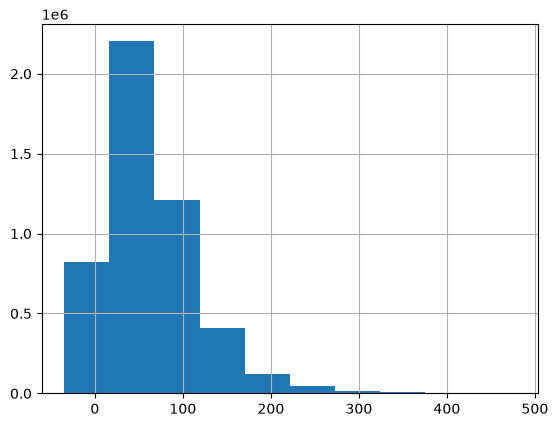

In [28]:
train['biomass'].hist()

array([[<Axes: title={'center': 'ndvi'}>,
        <Axes: title={'center': 'evi'}>,
        <Axes: title={'center': 'msavi'}>],
       [<Axes: title={'center': 'rvi'}>,
        <Axes: title={'center': 'HH_dB_palsar_xxxx'}>,
        <Axes: title={'center': 'HV_dB_palsar_xxxx'}>],
       [<Axes: title={'center': 'angle_palsar_xxxx'}>,
        <Axes: title={'center': 'vv.sentinel1_xxxx07'}>,
        <Axes: title={'center': 'vh.sentinel1_xxxx07'}>],
       [<Axes: title={'center': 'biomass'}>, <Axes: >, <Axes: >]],
      dtype=object)

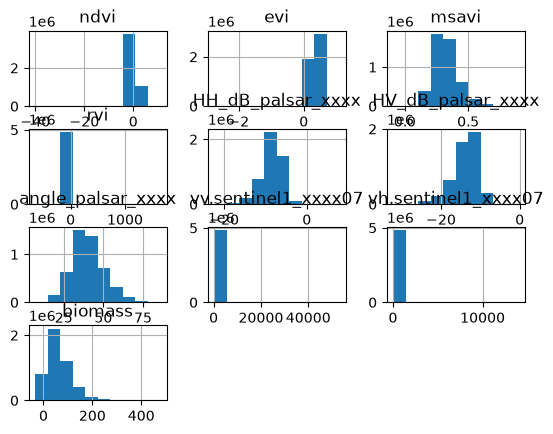

In [29]:
train.hist()

In [30]:
col = 'biomass'

train = train[[col] + [c for c in train.columns if c != col]]

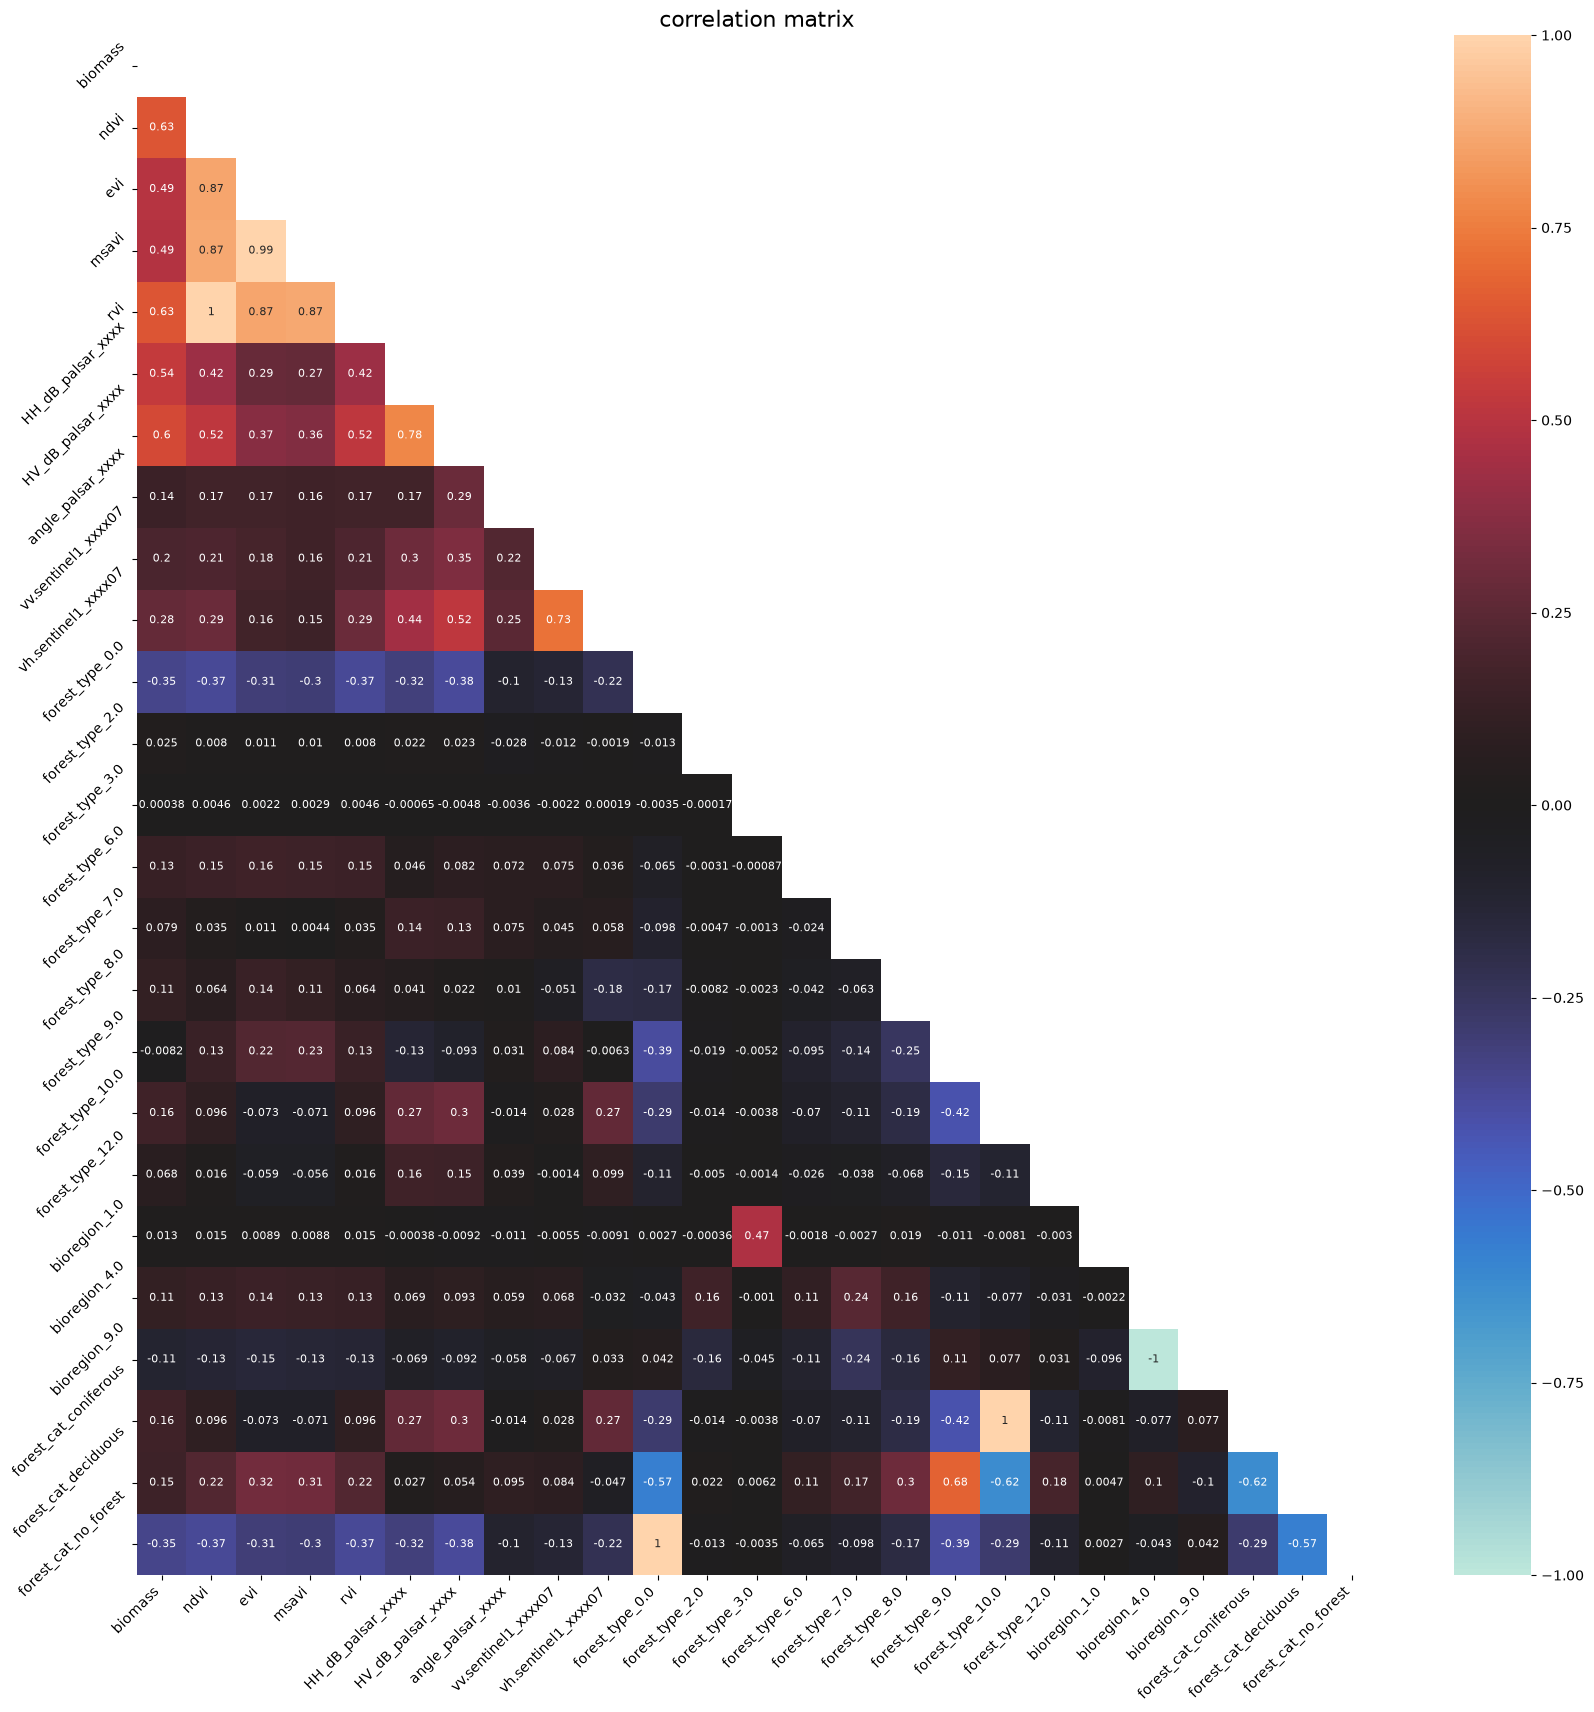

In [31]:
corr = train.corr(method='spearman')

mask = np.triu(np.ones(corr.shape)).astype(bool)

# Plot the heatmap
plt.figure(figsize=(20, 20))
ax = sns.heatmap(corr, annot=True, mask=mask,annot_kws={"size": 8},center=0, vmin=-1, vmax=1)
plt.title('correlation matrix', fontsize=16)
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10, rotation=45, ha='right') 
plt.show()

In [32]:
# Random Forest is capable of dealing with highly correlated covariates. However, SHAP is not (covariates of similar 
# influence get smaller values), so to get a clearer understanding of covariate importance, we need to remove high correlations.
# Furthermore, if the covariate does not correlate with the target, it will not contribute much to the model.
# Methodology of covariate reduction adapted from https://doi.org/10.1080/20964471.2026.2647582

# To be removed (correlation above 0.8) - EVI, MSAVI, RVI, forest_type_10.0, forest_type_0.0

# Also to be removed (almost no correlation with target, <0.1, will only add noise) - 
#forest_type_2.0, forest_type_3.0, forest_type_7.0, , forest_type_9.0, forest_type_12.0, bioregion_1.0

## 11. Select a representative sample based on the prediction target

In [33]:
# As there are too many rows to process easily (especially with SHAP), selecting representative sample based on biomass values.
# Divide target into 20 quantile bins
copy = train.copy()
copy["biomass_bin"] = pd.qcut(
    copy["biomass"],
    q=20,
    duplicates="drop"
)

# Take n observations from each bin
train_s = (
    copy
    .groupby("biomass_bin", group_keys=False)
    .sample(n=500, random_state=randomstate)
)
train_s = train_s.drop('biomass_bin', axis= 1)

## 12. Re-check correlations

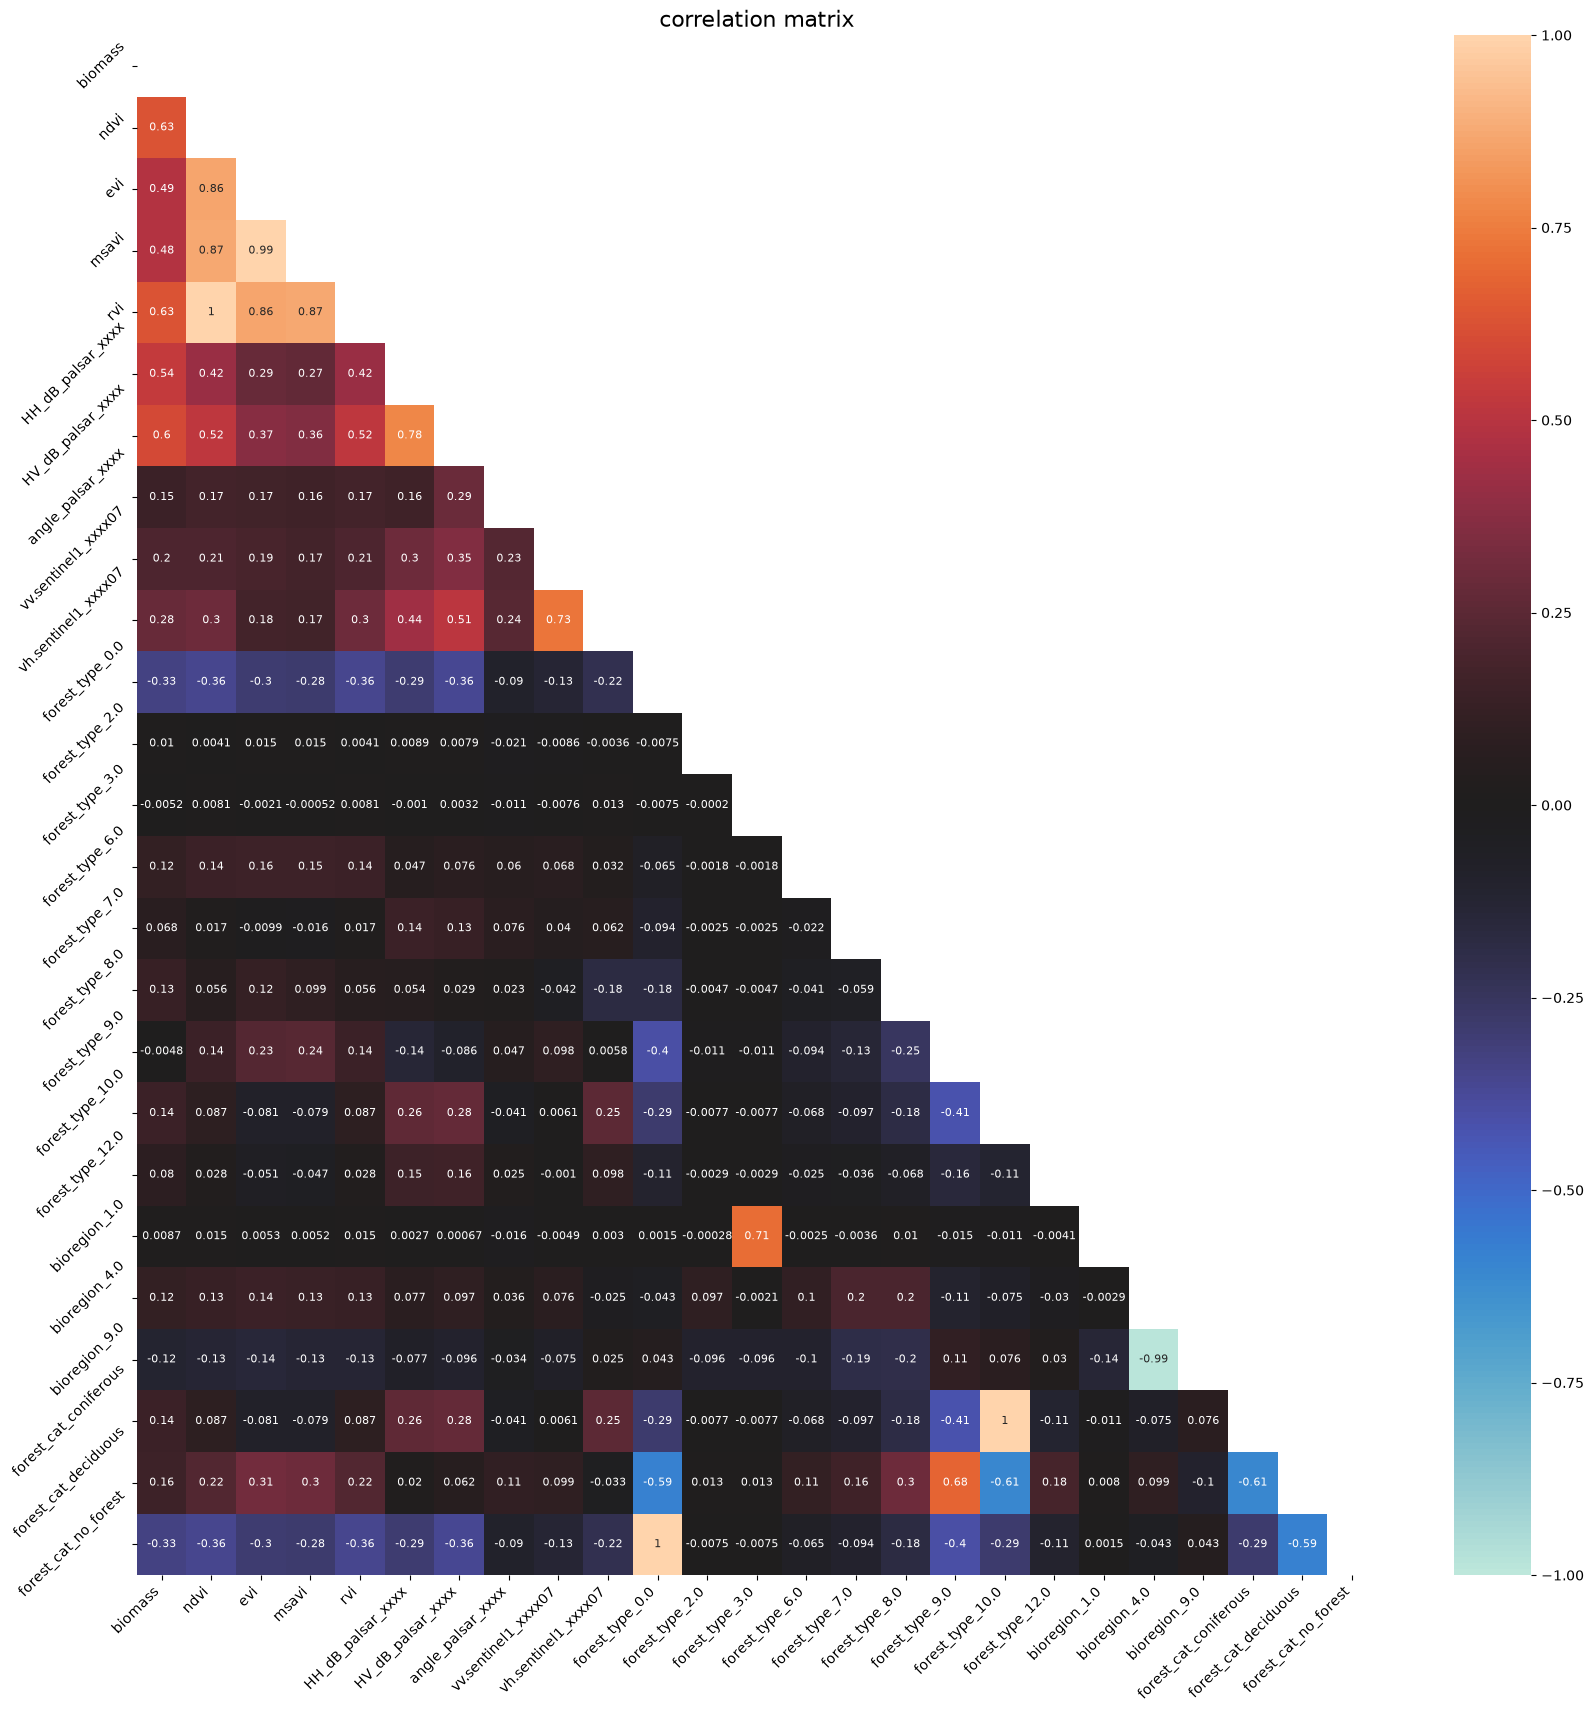

In [34]:
corr = train_s.corr(method='spearman')

mask = np.triu(np.ones(corr.shape)).astype(bool)

# Plot the heatmap
plt.figure(figsize=(20, 20))
ax = sns.heatmap(corr, annot=True, mask=mask,annot_kws={"size": 8},center=0, vmin=-1, vmax=1)
plt.title('correlation matrix', fontsize=16)
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10, rotation=45, ha='right') 
plt.show()

In [35]:
train_s.columns

Index(['biomass', 'ndvi', 'evi', 'msavi', 'rvi', 'HH_dB_palsar_xxxx',
       'HV_dB_palsar_xxxx', 'angle_palsar_xxxx', 'vv.sentinel1_xxxx07',
       'vh.sentinel1_xxxx07', 'forest_type_0.0', 'forest_type_2.0',
       'forest_type_3.0', 'forest_type_6.0', 'forest_type_7.0',
       'forest_type_8.0', 'forest_type_9.0', 'forest_type_10.0',
       'forest_type_12.0', 'bioregion_1.0', 'bioregion_4.0', 'bioregion_9.0',
       'forest_cat_coniferous', 'forest_cat_deciduous',
       'forest_cat_no_forest'],
      dtype='str')

## 13. Select the data for model training

In [36]:
X = train_s[['ndvi', 'HH_dB_palsar_xxxx', 'HV_dB_palsar_xxxx', 'vv.sentinel1_xxxx07', 'vh.sentinel1_xxxx07', 'bioregion_4.0', 'bioregion_9.0',
       'forest_type_6.0',  'forest_type_8.0','forest_cat_coniferous', 'forest_cat_deciduous','forest_cat_no_forest']]

y = train_s['biomass']

y = y.squeeze()

## 14. Split the data into train/test sets

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=randomstate)

In [38]:
check_X_y(X_train, y_train)

(array([[  0.69187222,  -6.9234767 , -10.04684353, ...,   0.        ,
           1.        ,   0.        ],
        [  0.79287379,  -4.92768145, -11.58753872, ...,   0.        ,
           1.        ,   0.        ],
        [  0.77263008,  -9.08457661, -12.90307713, ...,   0.        ,
           1.        ,   0.        ],
        ...,
        [  0.788774  ,  -8.56639385, -14.46942425, ...,   0.        ,
           1.        ,   0.        ],
        [  0.90013443,  -9.92651844, -12.13499165, ...,   0.        ,
           1.        ,   0.        ],
        [  0.61399126,  -9.65211201, -15.49539089, ...,   0.        ,
           0.        ,   1.        ]], shape=(7000, 12)),
 array([ 89.20679474, 143.41363525,  35.93109894, ...,  29.77940369,
        260.13467407,  27.16032982], shape=(7000,)))

## 15. Tune hyperparameters

In [39]:
def tune_hyperparameters(X_train, y_train):
    
    param_grid = { 
    'n_estimators': list(np.arange(50, 501, 100).astype(int)),
        
    'max_depth': [5, 10, 20],
        
   } 
    
    cv = KFold(n_splits=5, shuffle=True, random_state=randomstate)
    
    grid_search = GridSearchCV(RandomForestRegressor(random_state=randomstate), 
                           param_grid=param_grid, cv=cv, verbose=3, n_jobs=1, scoring="neg_root_mean_squared_error",) 
    
    grid_search.fit(X_train, y_train) 
    
    # extract the best hyperparameters
    hyperparameters = grid_search.best_params_
    
    hyperparameters['oob_score'] = True

    return hyperparameters

In [40]:
hyperparameters = tune_hyperparameters(X_train, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
[CV 1/5] END ....max_depth=5, n_estimators=50;, score=-40.106 total time=   1.0s
[CV 2/5] END ....max_depth=5, n_estimators=50;, score=-36.697 total time=   1.0s
[CV 3/5] END ....max_depth=5, n_estimators=50;, score=-35.782 total time=   1.3s
[CV 4/5] END ....max_depth=5, n_estimators=50;, score=-38.217 total time=   1.3s
[CV 5/5] END ....max_depth=5, n_estimators=50;, score=-36.649 total time=   1.0s
[CV 1/5] END ...max_depth=5, n_estimators=150;, score=-40.154 total time=   2.9s
[CV 2/5] END ...max_depth=5, n_estimators=150;, score=-36.778 total time=   2.8s
[CV 3/5] END ...max_depth=5, n_estimators=150;, score=-35.694 total time=   3.1s
[CV 4/5] END ...max_depth=5, n_estimators=150;, score=-38.086 total time=   3.6s
[CV 5/5] END ...max_depth=5, n_estimators=150;, score=-36.650 total time=   3.4s
[CV 1/5] END ...max_depth=5, n_estimators=250;, score=-40.136 total time=   5.6s
[CV 2/5] END ...max_depth=5, n_estimators=250;, 

## 16. Fit the best model

In [41]:
rf = RandomForestRegressor(random_state=0).set_params(**hyperparameters)
    
rfReg = rf.fit(X_train, y_train)

In [42]:
train_score_baseline = rfReg.predict(X_train)
test_score_baseline = rfReg.predict(X_test)
    
print("Rsq:", round(r2_score(y_train, train_score_baseline), 2), round(r2_score(y_test, test_score_baseline), 2),)
    
print("OOB:", round(rfReg.oob_score_, 2))
    
print("RMSE:", round(root_mean_squared_error(y_train, train_score_baseline), 2), round(root_mean_squared_error(y_test,test_score_baseline), 2))

Rsq: 0.71 0.46
OOB: 0.49
RMSE: 27.74 37.53


## 17. Explore covariate importances with SHAP

In [43]:
def calculate_and_plot_shap(model, X):

    shap_values = shap.TreeExplainer(model).shap_values(X, approximate=True)

    fig, ax = plt.subplots(figsize=(10, 10))

    # Summary plot - average impact (bar plot)
    shap.summary_plot(
        shap_values=shap_values,
        features=X,
        feature_names=X.columns,
        plot_type="bar",
        color='black',
        show=False)

    ax = plt.gca()
    
    # beeswarm plot
    fig, ax = plt.subplots(figsize=(10, 10))
    
    shap.summary_plot(shap_values=shap_values, features=X, feature_names=X.columns, show=False)

    ax = plt.gca()

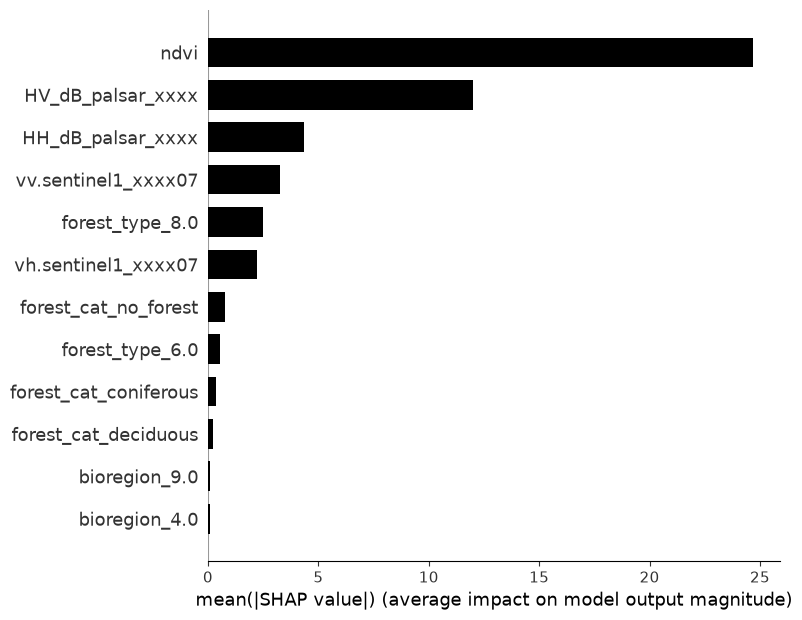

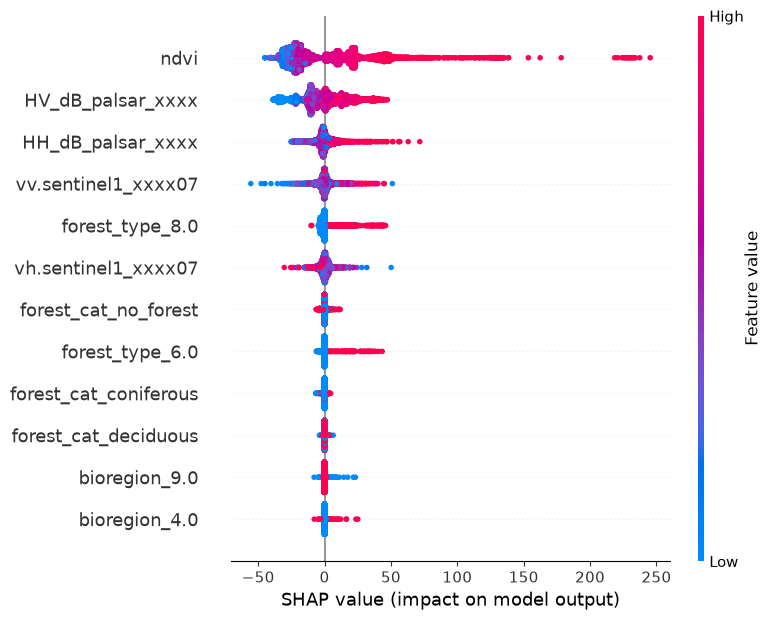

In [44]:
calculate_and_plot_shap(rfReg, X_train)

In [45]:
# Covariates forest_cat_no_forest and forest_cat_decidious show low contribution both on average (upper plot) and locally (lower plot),
# so they can be removed as well to generalise the model further.

## 18. Remove some covariates, as they contribute minimally

In [46]:
X_train.columns

Index(['ndvi', 'HH_dB_palsar_xxxx', 'HV_dB_palsar_xxxx', 'vv.sentinel1_xxxx07',
       'vh.sentinel1_xxxx07', 'bioregion_4.0', 'bioregion_9.0',
       'forest_type_6.0', 'forest_type_8.0', 'forest_cat_coniferous',
       'forest_cat_deciduous', 'forest_cat_no_forest'],
      dtype='str')

In [47]:
X_decreased = X_train.drop(['forest_cat_coniferous', 'forest_cat_deciduous'], axis=1)

## 19. Re-train the model

In [48]:
hyperparameters_decreased = tune_hyperparameters(X_decreased, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
[CV 1/5] END ....max_depth=5, n_estimators=50;, score=-40.107 total time=   0.9s
[CV 2/5] END ....max_depth=5, n_estimators=50;, score=-36.690 total time=   1.0s
[CV 3/5] END ....max_depth=5, n_estimators=50;, score=-35.768 total time=   0.9s
[CV 4/5] END ....max_depth=5, n_estimators=50;, score=-38.182 total time=   1.0s
[CV 5/5] END ....max_depth=5, n_estimators=50;, score=-36.645 total time=   1.1s
[CV 1/5] END ...max_depth=5, n_estimators=150;, score=-40.164 total time=   3.2s
[CV 2/5] END ...max_depth=5, n_estimators=150;, score=-36.765 total time=   3.9s
[CV 3/5] END ...max_depth=5, n_estimators=150;, score=-35.695 total time=   2.9s
[CV 4/5] END ...max_depth=5, n_estimators=150;, score=-38.073 total time=   2.8s
[CV 5/5] END ...max_depth=5, n_estimators=150;, score=-36.643 total time=   3.8s
[CV 1/5] END ...max_depth=5, n_estimators=250;, score=-40.143 total time=   5.9s
[CV 2/5] END ...max_depth=5, n_estimators=250;, 

In [49]:
rf = RandomForestRegressor(random_state=0).set_params(**hyperparameters_decreased)
    
rfReg_decreased = rf.fit(X_decreased, y_train)

In [50]:
train_decreased = rfReg_decreased.predict(X_decreased)
test_decreased = rfReg_decreased.predict(X_test.drop(['forest_cat_coniferous', 'forest_cat_deciduous'], axis=1))
    
print("Rsq:", round(r2_score(y_train, train_decreased), 2), round(r2_score(y_test, test_decreased), 2))
    
print("OOB:", round(rfReg.oob_score_, 2))
    
print("RMSE:", round(root_mean_squared_error(y_train, train_decreased), 2), round(root_mean_squared_error(y_test, test_decreased), 2))
    

Rsq: 0.71 0.45
OOB: 0.49
RMSE: 27.82 37.6


In [51]:
#As the score has not changed much, these covariates were indeed unnecessary.

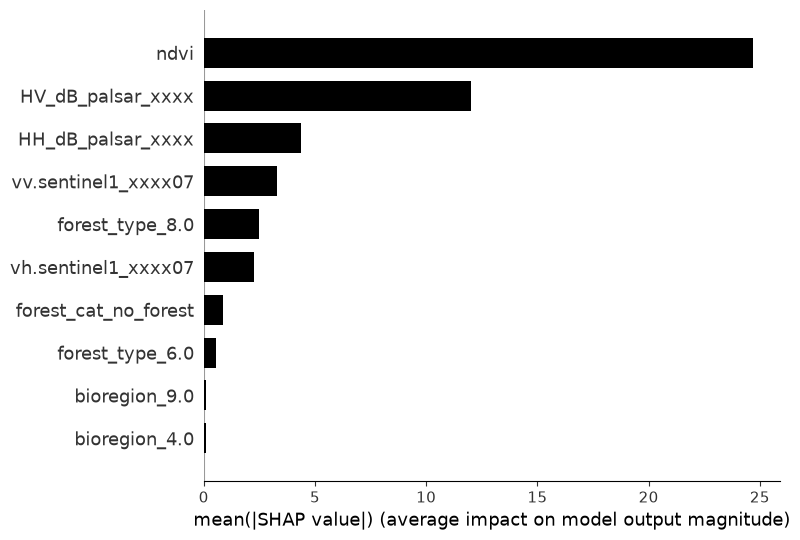

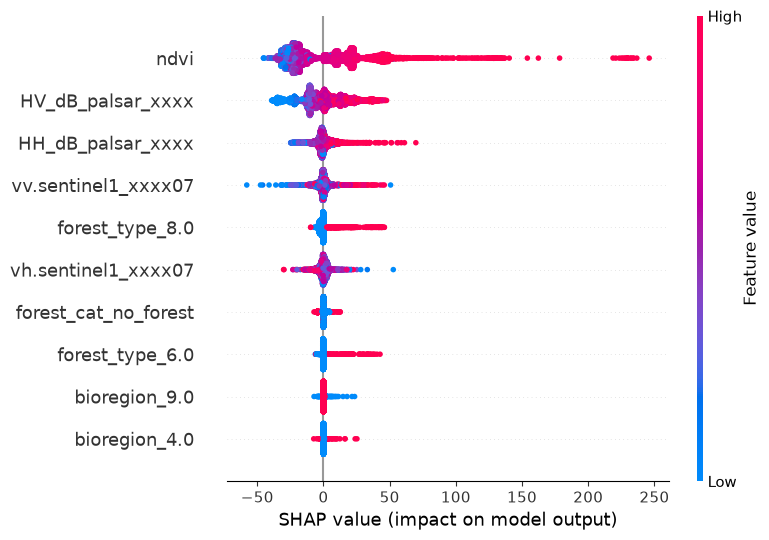

In [52]:
calculate_and_plot_shap(rfReg_decreased, X_decreased)

## 20. Pre-process data like in model training

In [53]:
test[red] = test[red] / 10000
test[nir] = test[nir] / 10000
test[blue] = test[blue] / 10000

In [54]:
# NDVI = NIR-RED/ NIR + RED
test['ndvi']  = (test[nir] - test[red]) / (test[nir] + test[red])

# EVI = 2.5 × (NIR − Red) / ((NIR + 6×Red − 7.5×Blue) + 1))
test['evi'] = 2.5 * ((test[nir] - test[red]) / ((test[nir] + 6 * test[red] - 7.5 * test[blue]) + 1))

# MSAVI = 	(2×NIR + 1 − √((2×NIR + 1)² − 8×(NIR − Red))) / 2
test['msavi'] = (2 * test[nir] + 1 - np.sqrt((2*test[nir] + 1)**2 - 8*(test[nir] - test[red]))) / 2

# RVI = NIR / Red
test['rvi'] = test[nir] / test[red]

In [55]:
test['forest_cat'] = test.apply(forest_type, axis= 1)

In [56]:
test = pd.get_dummies(test, columns= ['forest_type', 'bioregion', 'forest_cat'])

In [57]:
final_test_df = pd.concat([test[['row_id']], test[X_decreased.columns]], axis=1)

In [58]:
final_test_df

,row_id,ndvi,HH_dB_palsar_xxxx,HV_dB_palsar_xxxx,vv.sentinel1_xxxx07,vh.sentinel1_xxxx07,bioregion_4.0,bioregion_9.0,forest_type_6.0,forest_type_8.0,forest_cat_no_forest
0,028631_3040064_2251003,0.928744,-10.144670,-13.913869,4345.0,1192.0,False,True,False,False,False
1,028631_3041214_2252063,0.859174,-7.349724,-10.590984,1360.0,335.0,False,True,False,False,False
2,028631_3041184_2251693,0.951531,-6.874915,-12.238380,2078.0,615.0,False,True,False,False,False
3,028631_3039864_2250783,0.917894,-5.991528,-10.575653,2116.0,548.0,False,True,False,False,False
4,028631_3040224_2251483,0.954404,-6.046557,-10.341457,2367.0,385.0,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
45014,061751_3374644_2043173,0.862990,-9.803984,-15.310058,1363.0,397.0,False,True,False,False,False
45015,061751_3374594_2043203,0.603782,-11.813272,-15.730301,1387.0,277.0,False,True,False,False,True
45016,061751_3374624_2043173,0.840191,-11.729067,-16.882254,1336.0,308.0,False,True,False,False,False
45017,061751_3374614_2043223,0.876967,-7.831328,-13.507510,2629.0,603.0,False,True,False,False,True


In [59]:
final_test_df[final_test_df.isna().any(axis=1)]

,row_id,ndvi,HH_dB_palsar_xxxx,HV_dB_palsar_xxxx,vv.sentinel1_xxxx07,vh.sentinel1_xxxx07,bioregion_4.0,bioregion_9.0,forest_type_6.0,forest_type_8.0,forest_cat_no_forest
16508,028631_3040724_2252103,NaN,-5.517093,-14.141607,1261.0,328.0,False,True,False,False,False
29893,028631_3040714_2252103,NaN,-6.192622,-14.581549,1261.0,328.0,False,True,False,False,False
34595,062332_3379884_1993643,0.202050,-6.426341,-13.472488,NaN,577.0,False,True,False,False,True
39092,062332_3379904_1993653,0.541132,-7.587216,-13.341626,NaN,740.0,False,True,False,False,False
39439,062332_3379904_1993663,0.144256,-6.539370,-12.836405,NaN,740.0,False,True,False,False,False
40205,062332_3379894_1993653,0.224744,-6.183509,-13.196547,NaN,968.0,False,True,False,False,True
40544,062332_3379884_1993633,0.327921,-7.529390,-14.330029,NaN,577.0,False,True,False,False,True


## 21. Predict using the trained model

In [60]:
predictions = rfReg_decreased.predict(final_test_df.drop('row_id', axis=1))
predictions

array([210.00573687,  99.73731255, 274.04436707, ..., 100.77115691,
       167.79137462, 108.90663577], shape=(45019,))

In [61]:
len(predictions)

45019

In [62]:
preds = pd.DataFrame(predictions)

print(len(preds[preds.isna().any(axis=1)]))

preds

0


,0
0,210.005737
1,99.737313
2,274.044367
3,178.357250
4,344.523255
...,...
45014,91.087776
45015,35.960546
45016,100.771157
45017,167.791375


In [63]:
preds_to_export = pd.concat([pd.DataFrame(predictions), final_test_df], axis=1)

preds_to_export

,0,row_id,ndvi,HH_dB_palsar_xxxx,HV_dB_palsar_xxxx,vv.sentinel1_xxxx07,vh.sentinel1_xxxx07,bioregion_4.0,bioregion_9.0,forest_type_6.0,forest_type_8.0,forest_cat_no_forest
0,210.005737,028631_3040064_2251003,0.928744,-10.144670,-13.913869,4345.0,1192.0,False,True,False,False,False
1,99.737313,028631_3041214_2252063,0.859174,-7.349724,-10.590984,1360.0,335.0,False,True,False,False,False
2,274.044367,028631_3041184_2251693,0.951531,-6.874915,-12.238380,2078.0,615.0,False,True,False,False,False
3,178.357250,028631_3039864_2250783,0.917894,-5.991528,-10.575653,2116.0,548.0,False,True,False,False,False
4,344.523255,028631_3040224_2251483,0.954404,-6.046557,-10.341457,2367.0,385.0,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
45014,91.087776,061751_3374644_2043173,0.862990,-9.803984,-15.310058,1363.0,397.0,False,True,False,False,False
45015,35.960546,061751_3374594_2043203,0.603782,-11.813272,-15.730301,1387.0,277.0,False,True,False,False,True
45016,100.771157,061751_3374624_2043173,0.840191,-11.729067,-16.882254,1336.0,308.0,False,True,False,False,False
45017,167.791375,061751_3374614_2043223,0.876967,-7.831328,-13.507510,2629.0,603.0,False,True,False,False,True


In [64]:
preds_to_export.rename(columns={preds_to_export.columns[0]: "Expected"}, inplace=True)

preds_to_export.rename(columns={preds_to_export.columns[1]: "Id"}, inplace=True)

preds_to_export

,Expected,Id,ndvi,HH_dB_palsar_xxxx,HV_dB_palsar_xxxx,vv.sentinel1_xxxx07,vh.sentinel1_xxxx07,bioregion_4.0,bioregion_9.0,forest_type_6.0,forest_type_8.0,forest_cat_no_forest
0,210.005737,028631_3040064_2251003,0.928744,-10.144670,-13.913869,4345.0,1192.0,False,True,False,False,False
1,99.737313,028631_3041214_2252063,0.859174,-7.349724,-10.590984,1360.0,335.0,False,True,False,False,False
2,274.044367,028631_3041184_2251693,0.951531,-6.874915,-12.238380,2078.0,615.0,False,True,False,False,False
3,178.357250,028631_3039864_2250783,0.917894,-5.991528,-10.575653,2116.0,548.0,False,True,False,False,False
4,344.523255,028631_3040224_2251483,0.954404,-6.046557,-10.341457,2367.0,385.0,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
45014,91.087776,061751_3374644_2043173,0.862990,-9.803984,-15.310058,1363.0,397.0,False,True,False,False,False
45015,35.960546,061751_3374594_2043203,0.603782,-11.813272,-15.730301,1387.0,277.0,False,True,False,False,True
45016,100.771157,061751_3374624_2043173,0.840191,-11.729067,-16.882254,1336.0,308.0,False,True,False,False,False
45017,167.791375,061751_3374614_2043223,0.876967,-7.831328,-13.507510,2629.0,603.0,False,True,False,False,True


In [65]:
preds_to_export[['Id', 'Expected']].to_csv("submission.csv", index=False)